# Hand Gesture Recognition (Multi-Agent Security System)
### Built with EfficientNet-B0 + HaGRID Dataset
---

This notebook builds a **real-time hand gesture recognition system** that can be used as a security interface.  
A user performs a hand gesture in front of a webcam, the system recognises it, and maps it to a security action (e.g. "like" → Access Granted, "fist" → Alert Triggered).



##How Does it Actually Work?
```
Webcam Frame
    │
    ▼
MediaPipe Hand Landmarker   ← detects hand & produces bounding box
    │
    ▼
Crop + Pad (30%)            ← isolates the hand, removes background
    │
    ▼
EfficientNet-B0             ← classifies gesture (18 classes)
    │
    ▼
Security Action Mapping     ← gesture → human-readable security command
```


###Dataset details
####HaGRID (Hand Gesture Recognition Image Dataset)
- **30,000 images** at 384p resolution
- **18 gesture classes**: call, dislike, fist, four, like, mute, ok, one, palm, peace, peace_inverted, rock, stop, stop_inverted, three, three2, two_up, two_up_inverted
- Each image comes with bounding-box annotations in JSON format
- Source: [HaGRID on Kaggle](https://www.kaggle.com/datasets/kapitanov/hagrid)


### Key Design Decisions
| Decision | Reason |
|---|---|
| EfficientNet-B0 | Excellent accuracy/speed tradeoff; pretrained on ImageNet |
| Hand cropping at train & inference | Forces model to focus on hand shape, not background |
| MediaPipe for runtime detection | Fast CPU-based landmark detection; no GPU needed |
| Python pull-loop for camera | Avoids Colab kernel bridge data corruption |



##Imports


In [1]:
%pip install torch torchvision #For the prebuilt model (EfficientNet)/ Image transformation and data loading

In [2]:
#Imports
import os, json, random, urllib, shutil, warnings
warnings.filterwarnings('ignore')
!pip install kagglehub huggingface_hub -q
import kagglehub
from huggingface_hub import snapshot_download
import numpy as np
from glob import glob
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import torch
from torch import nn
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix
import zipfile

#Checking that I am on GPU not CPU because cpu is too slow
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f' Device  : {device}')
print(f' PyTorch : {torch.__version__}')

 Device  : cuda
 PyTorch : 2.10.0+cu128


##Downloading Dataset its (Annotations and Images)

In [3]:
# Download annotations via kagglehub
path = kagglehub.dataset_download('kapitanov/hagrid')
print(f' Annotations path: {path}')

# Download images from HuggingFace
print('\n Downloading images (~1GB)...')
snapshot_download(
    repo_id='cj-mills/hagrid-sample-30k-384p',
    repo_type='dataset',
    local_dir='/content/hagrid_images'
)
print('Images downloaded!')

Using Colab cache for faster access to the 'hagrid' dataset.
 Annotations path: /kaggle/input/hagrid



Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Images downloaded!


##Extracting dataset
Dataset was downloaded as a zip file so I had to unzip it.

In [4]:
#plan A in unziping
print(' Extracting images...')
# The HuggingFace snapshot downloads a single zip file containing all images.

zip_path = '/content/hagrid_images/hagrid-sample-30k-384p.zip'
extract_path = '/content/hagrid_images/'

# Create destination directory if it doesn't already exist
os.makedirs(extract_path, exist_ok=True)

# Used the system 'unzip' command with -q (quiet) flag to suppress output because this is is faster than Python's zipfile for large archives.
os.system(f'unzip -q "{zip_path}" -d "{extract_path}"')

print('Extraction complete!')

# Quick check what got extracted
print("\n Extracted folders:")
print(os.listdir(extract_path))

 Extracting images...
Extraction complete!

 Extracted folders:
['.cache', 'README.md', 'hagrid-sample-30k-384p', '.gitattributes', 'hagrid-sample-30k-384p.zip']


In [5]:
# plan B if the first zipping failed
base_dir = "/content/hagrid_images"
zip_path = os.path.join(base_dir, "hagrid-sample-30k-384p.zip")

print(" Extracting...")

# Alternative extraction using Python's built-in zipfile module. ZipFile handles large archives safely without loading everything into memory.
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(base_dir)

print("Done")

print("\n After extraction:")
print(os.listdir(base_dir))

 Extracting...
Done

 After extraction:
['.cache', 'README.md', 'hagrid-sample-30k-384p', '.gitattributes', 'hagrid-sample-30k-384p.zip']


##Locating Annotation and Image paths

In [6]:
import os

base_dir = "/content/hagrid_images"

print(" Root:", os.listdir(base_dir))

# directly search full tree
img_base = None
ann_base = None

for root, dirs, files in os.walk(base_dir):
    if "hagrid_30k" in dirs:
        img_base = os.path.join(root, "hagrid_30k")
    if "ann_train_val" in dirs:
        ann_base = os.path.join(root, "ann_train_val")

print("\n Image path:", img_base)
print(" Annotation path:", ann_base)

if img_base is None or ann_base is None:
    print("\n❌ Full directory dump:")
    for r, d, f in os.walk(base_dir):
        print(r)
    raise FileNotFoundError("Dataset not found after extraction")

 Root: ['.cache', 'README.md', 'hagrid-sample-30k-384p', '.gitattributes', 'hagrid-sample-30k-384p.zip']

 Image path: /content/hagrid_images/hagrid-sample-30k-384p/hagrid_30k
 Annotation path: /content/hagrid_images/hagrid-sample-30k-384p/ann_train_val


##Visualise Sample Images using Bounding Boxes


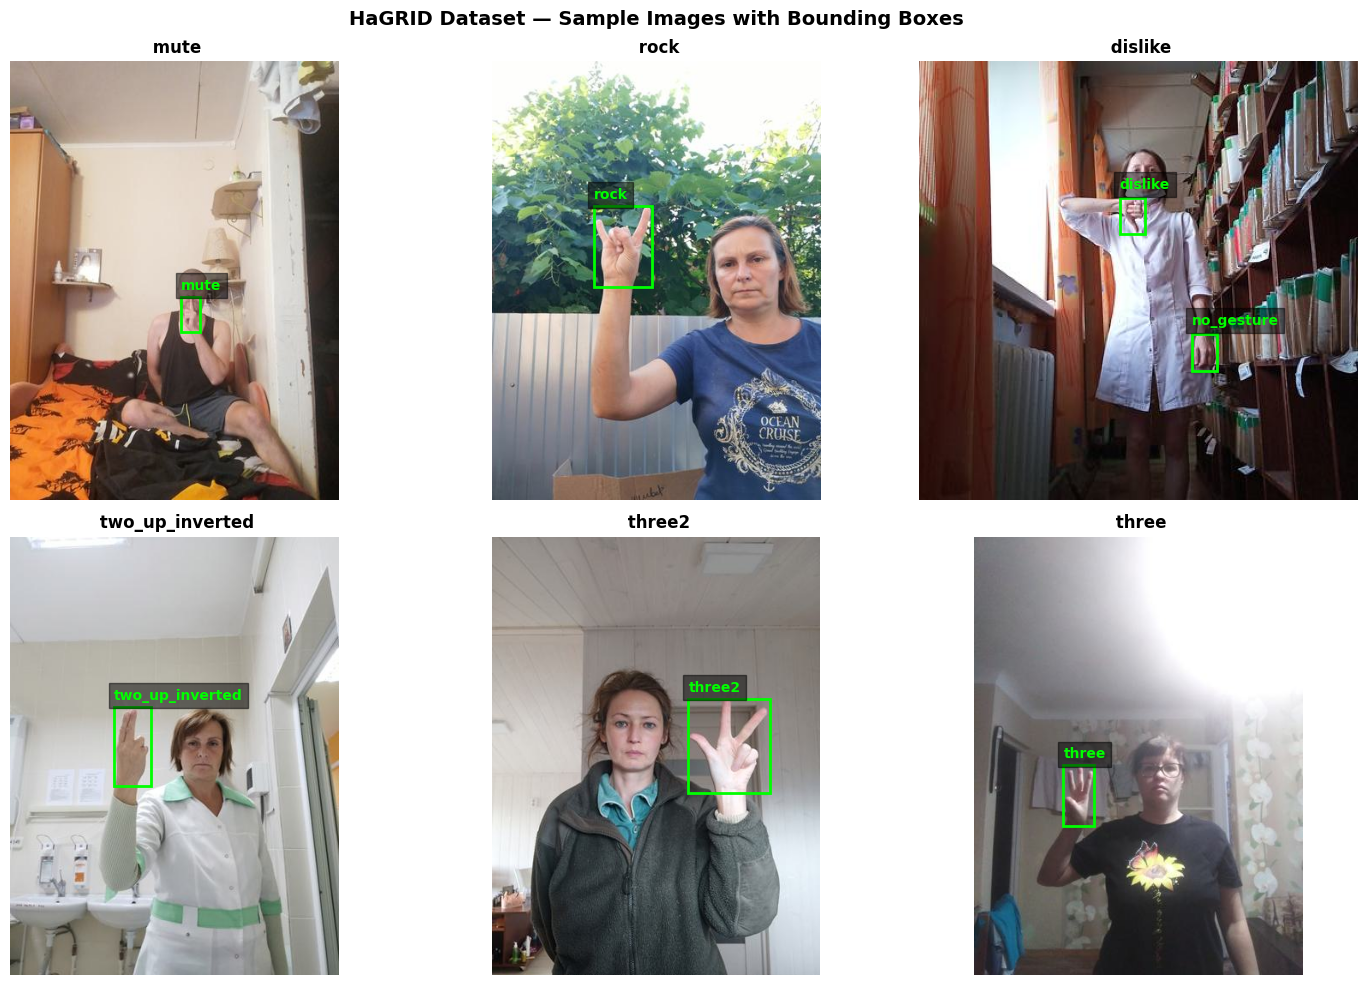

In [7]:
# Randomly pick 6 gesture classes and display one sample image from each.
# We overlay the ground-truth bounding box from the annotation JSON
# so we can visually confirm the dataset loaded correctly.

gesture_folders = [
    f for f in os.listdir(img_base)
    if os.path.isdir(f'{img_base}/{f}')   # only include directories (gesture folders)
]
sample_gestures = random.sample(gesture_folders, 6)  # pick 6 at random

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()   # convert 2D grid to flat list for easy iteration

for ax, folder in zip(axes, sample_gestures):
    # Strip the 'train_val_' prefix to get the clean gesture name
    gesture_name = folder.replace('train_val_', '')

    # Pick a random image from this gesture's folder
    images   = glob(f'{img_base}/{folder}/*.jpg')
    img_path = random.choice(images)
    img      = Image.open(img_path).convert('RGB')
    w, h     = img.size   # needed to convert normalised bbox coords to pixels

    # Load annotation JSON for this gesture class
    ann_file = f'{ann_base}/{gesture_name}.json'
    img_id   = os.path.basename(img_path).replace('.jpg', '')   # annotation key
    with open(ann_file) as f:
        anns = json.load(f)

    ax.imshow(img)

    # Draw each bounding box if this image has annotations
    if img_id in anns:
        for bbox, label in zip(anns[img_id]['bboxes'], anns[img_id]['labels']):
            x, y, bw, bh = bbox   # normalised: x,y = top-left corner; bw,bh = size

            # Convert normalised [0,1] coordinates to pixel coordinates
            rect = patches.Rectangle(
                (x*w, y*h), bw*w, bh*h,
                linewidth=2, edgecolor='lime', facecolor='none'
            )
            ax.add_patch(rect)

            # Label text above the box
            ax.text(x*w, y*h-8, label, color='lime', fontsize=10,
                    weight='bold', bbox=dict(facecolor='black', alpha=0.5))

    ax.set_title(f' {gesture_name}', fontsize=12, weight='bold')
    ax.axis('off')

plt.suptitle('HaGRID Dataset — Sample Images with Bounding Boxes',
             fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

In [8]:
# view class labels in a sorted way
class_names = sorted([
    folder.replace('train_val_', '')
    for folder in os.listdir(img_base)
    if os.path.isdir(f'{img_base}/{folder}')
])
class_to_idx = {name: idx for idx, name in enumerate(class_names)}
idx_to_class = {idx: name for name, idx in class_to_idx.items()}

print(f' {len(class_names)} classes discovered from data:\n')
for idx, name in idx_to_class.items():
    print(f'   {idx:02d} → {name}')

 18 classes discovered from data:

   00 → call
   01 → dislike
   02 → fist
   03 → four
   04 → like
   05 → mute
   06 → ok
   07 → one
   08 → palm
   09 → peace
   10 → peace_inverted
   11 → rock
   12 → stop
   13 → stop_inverted
   14 → three
   15 → three2
   16 → two_up
   17 → two_up_inverted


##Image Tranformations and Data Augmentation
###Transforms does two things

  1. Normalise images into the format EfficientNet expects (224×224, ImageNet stats)
  2. Augment training images to make the model robust to real-world variation

In [9]:

train_transform = T.Compose([

    T.RandomResizedCrop(224, scale=(0.8, 1.0)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(15),
    T.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1), shear=10),
    T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406],
                [0.229, 0.224, 0.225])
])

val_transform = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize([0.485, 0.456, 0.406],
                [0.229, 0.224, 0.225])
])

print('Transforms defined!')
print('   Train: RandomResizedCrop + Flip + Rotation + Affine + ColorJitter')
print('   Val  : Resize only (no augmentation)')

Transforms defined!
   Train: RandomResizedCrop + Flip + Rotation + Affine + ColorJitter
   Val  : Resize only (no augmentation)


In [10]:
#Customized Dataset Class with Hand Cropping
# feeding to the model removes background noise and focuses
# purely on the hand shape to give higher accuracy

class HaGRIDDataset(Dataset):
    def __init__(self, img_base, ann_base, class_to_idx, transform=None):
        self.transform    = transform
        self.class_to_idx = class_to_idx
        self.samples      = []  # (img_path, label, bbox)

        for gesture in class_to_idx.keys():
            folder   = f'{img_base}/train_val_{gesture}'
            ann_file = f'{ann_base}/{gesture}.json'
            if not os.path.exists(folder) or not os.path.exists(ann_file):
                continue
            with open(ann_file) as f:
                anns = json.load(f)
            for img_file in glob(f'{folder}/*.jpg'):
                img_id = os.path.basename(img_file).replace('.jpg', '')
                if img_id in anns:
                    ann    = anns[img_id]
                    labels = ann['labels']
                    bboxes = ann['bboxes']

                    # Find bbox of the gesture hand (matches folder/gesture name)
                    gesture_bbox = None
                    for label, bbox in zip(labels, bboxes):
                        if label == gesture:
                            gesture_bbox = bbox
                            break

                    # Fallback: use first bbox
                    if gesture_bbox is None and len(bboxes) > 0:
                        gesture_bbox = bboxes[0]

                    self.samples.append((
                        img_file,
                        class_to_idx[gesture],
                        gesture_bbox
                    ))

        print(f'Dataset: {len(self.samples)} samples loaded (with hand crops)')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label, bbox = self.samples[idx]
        img = Image.open(img_path).convert('RGB')
        w, h = img.size

        # ── CROP THE HAND REGION ─────────────────────────────
        if bbox is not None:
            x, y, bw, bh = bbox

            # Convert normalized coords to pixels
            x1 = int(x * w)
            y1 = int(y * h)
            x2 = int((x + bw) * w)
            y2 = int((y + bh) * h)

            # Add 20% padding around hand for context
            pad_x = int(bw * w * 0.20)
            pad_y = int(bh * h * 0.20)
            x1 = max(0, x1 - pad_x)
            y1 = max(0, y1 - pad_y)
            x2 = min(w, x2 + pad_x)
            y2 = min(h, y2 + pad_y)

            # Only crop if valid region
            if x2 > x1 and y2 > y1:
                img = img.crop((x1, y1, x2, y2))

        if self.transform:
            img = self.transform(img)
        return img, label

print(' HaGRIDDataset with hand cropping defined!')
print('   → Model now sees only the hand, not the background')


 HaGRIDDataset with hand cropping defined!
   → Model now sees only the hand, not the background


Train and Validate the dataloaders


In [11]:
full_dataset = HaGRIDDataset(
    img_base, ann_base, class_to_idx,
    transform=train_transform
)

train_size = int(0.8 * len(full_dataset))
val_size   = len(full_dataset) - train_size

train_set, val_set = torch.utils.data.random_split(
    full_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

# Val set uses val_transform (no augmentation)
val_set.dataset.transform = val_transform

train_loader = DataLoader(train_set, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_set,   batch_size=32, shuffle=False, num_workers=2)

print(f'Train samples : {len(train_set)}')
print(f'Val samples   : {len(val_set)}')
print(f'Train batches : {len(train_loader)}')
print(f' Val batches   : {len(val_loader)}')

Dataset: 31833 samples loaded (with hand crops)
Train samples : 25466
Val samples   : 6367
Train batches : 796
 Val batches   : 199


Build the EfficientNet-B0 Model

In [12]:
# ── Cell 11: Build Model (EfficientNet-B0) ───────────────────
model = efficientnet_b0(weights=EfficientNet_B0_Weights.IMAGENET1K_V1)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, len(class_names))
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f'Model          : EfficientNet-B0')
print(f'Output classes : {len(class_names)}')
print(f'Total params   : {total_params:,}')
print(f'Device         : {device}')

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 146MB/s]


Model          : EfficientNet-B0
Output classes : 18
Total params   : 4,030,606
Device         : cuda


Training the model


In [13]:
# ── Cell 12: Train ───────────────────────────────────────────
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.3)

best_val_acc = 0
num_epochs   = 15

# Lists to store metrics for plotting
train_losses = []
train_accs = []
val_accs = []

print(' Training EfficientNet-B0...\n')
print(f'{"Epoch":<8} {"Train Loss":<14} {"Train Acc":<12} {"Val Acc":<10} {"Status"}')
print('─' * 55)

for epoch in range(num_epochs):
    # Training
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0

    for images, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}', leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss    += loss.item() * images.size(0)
        _, predicted   = outputs.max(1)
        train_correct += predicted.eq(labels).sum().item()
        train_total   += images.size(0)

    # Validation
    model.eval()
    val_correct, val_total = 0, 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs        = model(images)
            _, predicted   = outputs.max(1)
            val_correct   += predicted.eq(labels).sum().item()
            val_total     += images.size(0)

    train_loss_avg = train_loss / train_total
    train_acc      = 100 * train_correct / train_total
    val_acc        = 100 * val_correct / val_total
    scheduler.step()

    # Store metrics
    train_losses.append(train_loss_avg)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    status = ''
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')
        status = ' saved'

    print(f'{epoch+1:<8} {train_loss_avg:<14.4f} {train_acc:<12.2f} {val_acc:<10.2f} {status}')

print(f'\n Best Val Accuracy: {best_val_acc:.2f}%')
print(f' Best model saved to: best_model.pth')

 Training EfficientNet-B0...

Epoch    Train Loss     Train Acc    Val Acc    Status
───────────────────────────────────────────────────────


1        0.2578         92.19        97.97       saved


2        0.0865         97.29        98.54       saved


3        0.0733         97.62        97.68      


4        0.0640         98.09        96.21      


...

11       0.0055         99.89        99.29       saved


12       0.0030         99.95        99.51       saved


13       0.0024         99.97        99.42      


14       0.0040         99.92        99.37      


15       0.0027         99.96        99.43      

 Best Val Accuracy: 99.51%
 Best model saved to: best_model.pth


Confusion Matrix





Evaluating: 100%|██████████| 199/199 [00:21<00:00,  9.37it/s]


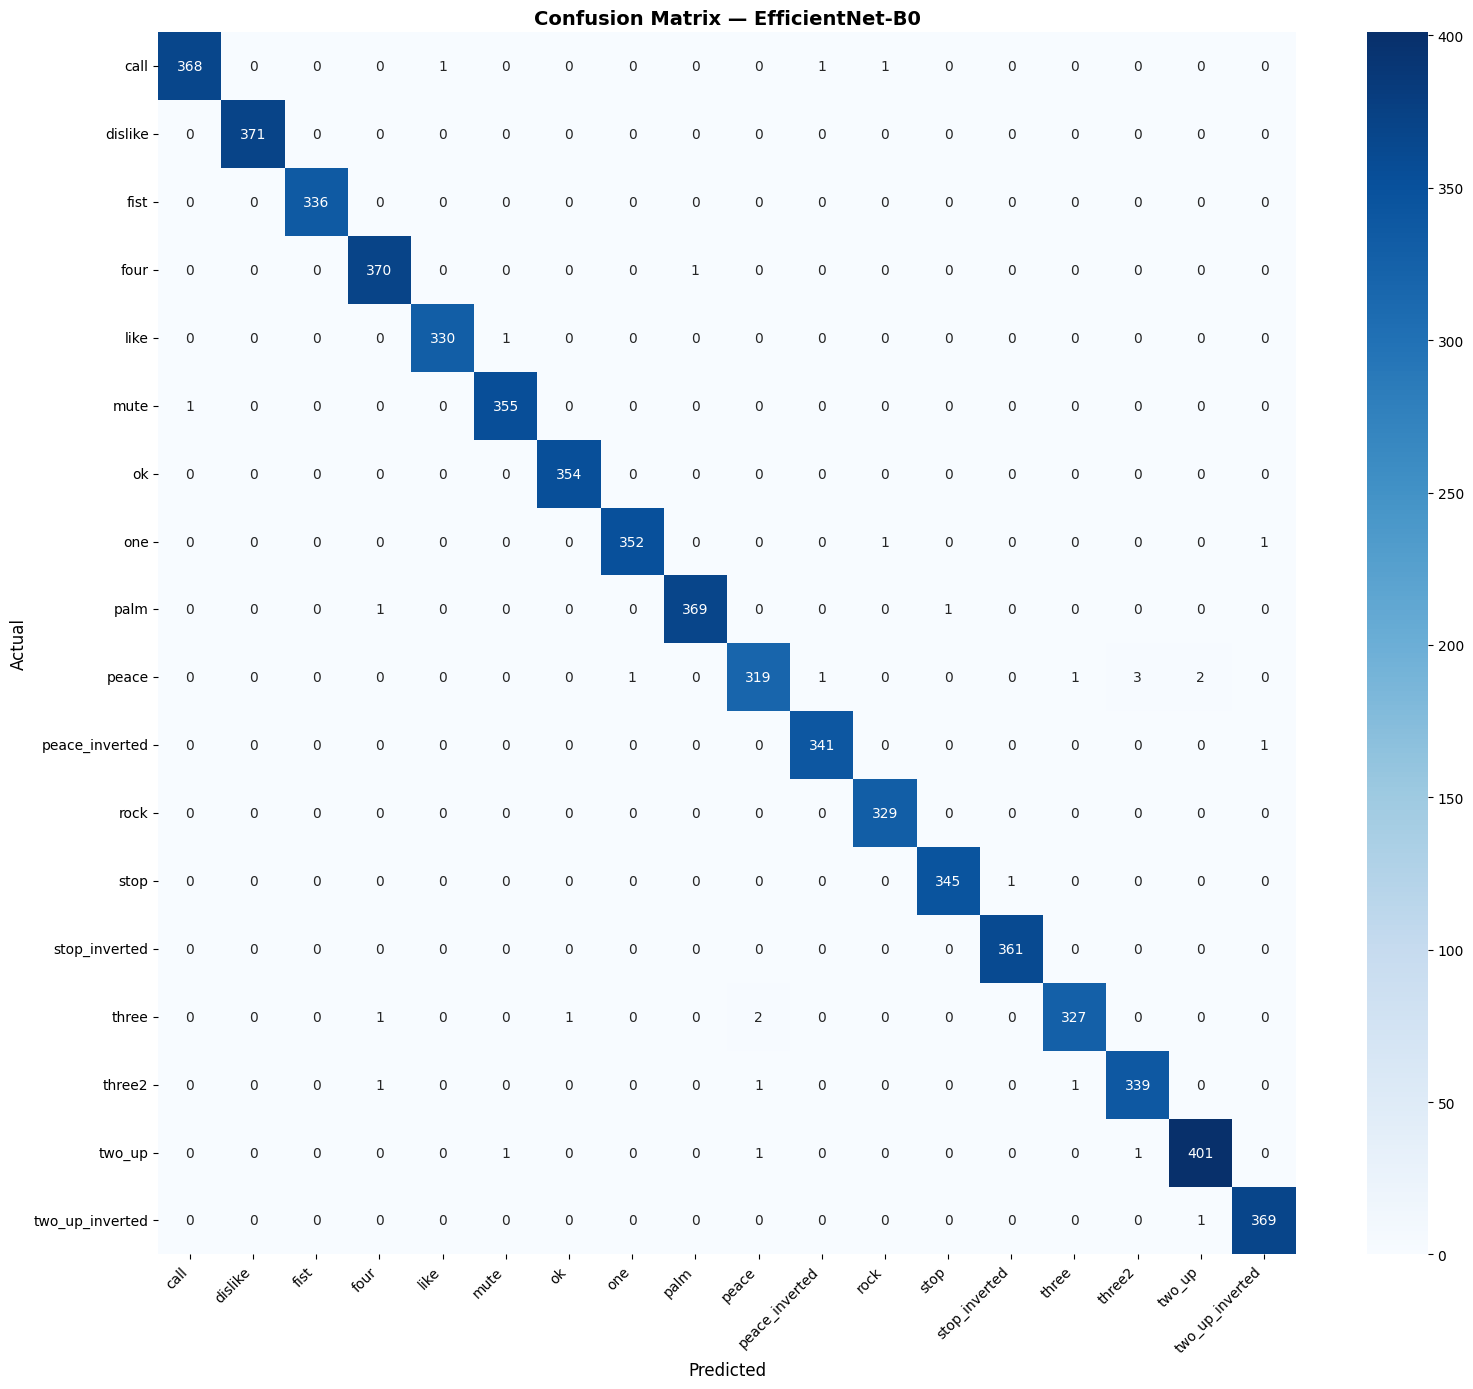

In [14]:
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in tqdm(val_loader, desc='Evaluating'):
        images  = images.to(device)
        outputs = model(images)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(16, 14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('Actual',    fontsize=12)
plt.title('Confusion Matrix — EfficientNet-B0', fontsize=14, weight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



Classification Report:
                 precision    recall  f1-score   support

           call       1.00      0.99      0.99       371
        dislike       1.00      1.00      1.00       371
           fist       1.00      1.00      1.00       336
           four       0.99      1.00      0.99       371
           like       1.00      1.00      1.00       331
           mute       0.99      1.00      1.00       356
             ok       1.00      1.00      1.00       354
            one       1.00      0.99      1.00       354
           palm       1.00      0.99      1.00       371
          peace       0.99      0.98      0.98       327
 peace_inverted       0.99      1.00      1.00       342
           rock       0.99      1.00      1.00       329
           stop       1.00      1.00      1.00       346
  stop_inverted       1.00      1.00      1.00       361
          three       0.99      0.99      0.99       331
         three2       0.99      0.99      0.99       342
      

Getting probabilities: 100%|██████████| 199/199 [00:22<00:00,  8.84it/s]


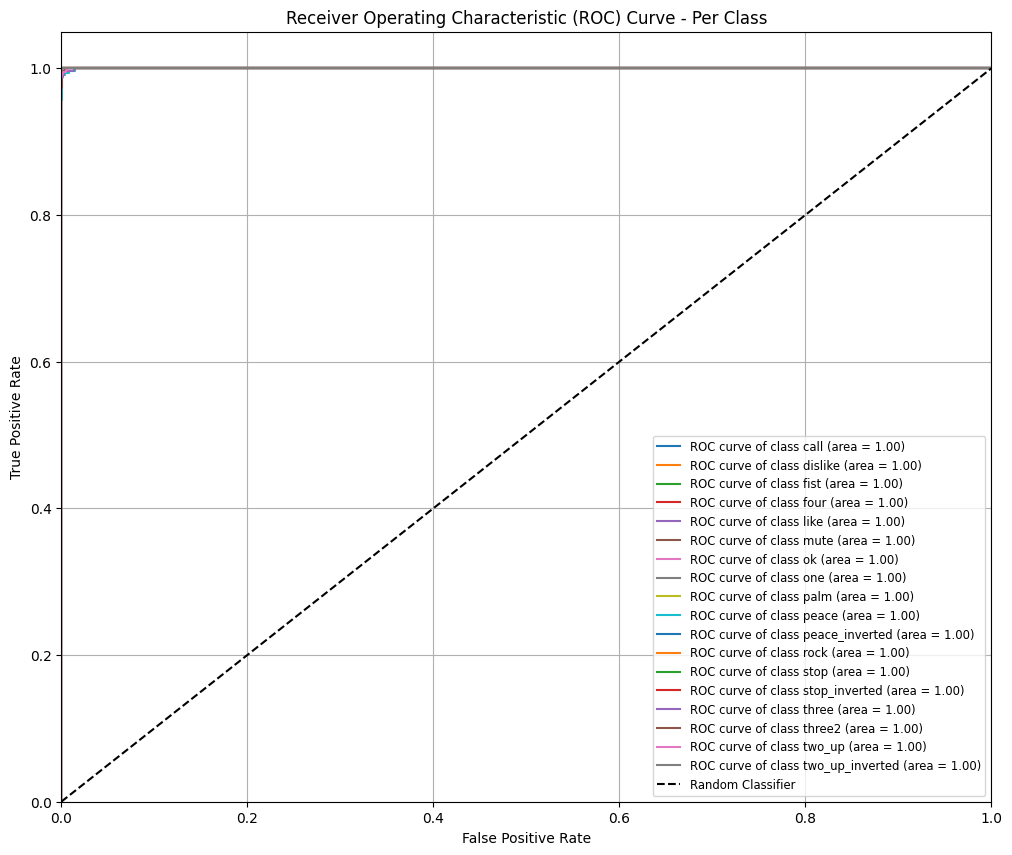

In [15]:
from sklearn.metrics import classification_report, roc_curve, auc

# Classification Report
print('\nClassification Report:')
print(classification_report(all_labels, all_preds, target_names=class_names))

# ROC Curve and AUC for each class
plt.figure(figsize=(12, 10))

# Convert labels to one-hot encoding for ROC curve calculation
from sklearn.preprocessing import label_binarize
binary_labels = label_binarize(all_labels, classes=range(len(class_names)))

# Get probabilities for all classes from the model
# Need to re-run prediction to get probabilities
all_probs = []
model.eval()
with torch.no_grad():
    for images, _ in tqdm(val_loader, desc='Getting probabilities'):
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        all_probs.extend(probs.cpu().numpy())

all_probs = np.array(all_probs)

for i, class_name in enumerate(class_names):
    fpr, tpr, _ = roc_curve(binary_labels[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'ROC curve of class {class_name} (area = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - Per Class')
plt.legend(loc='lower right', fontsize='small')
plt.grid(True)
plt.show()


Visual Model Test on Dataset Samples

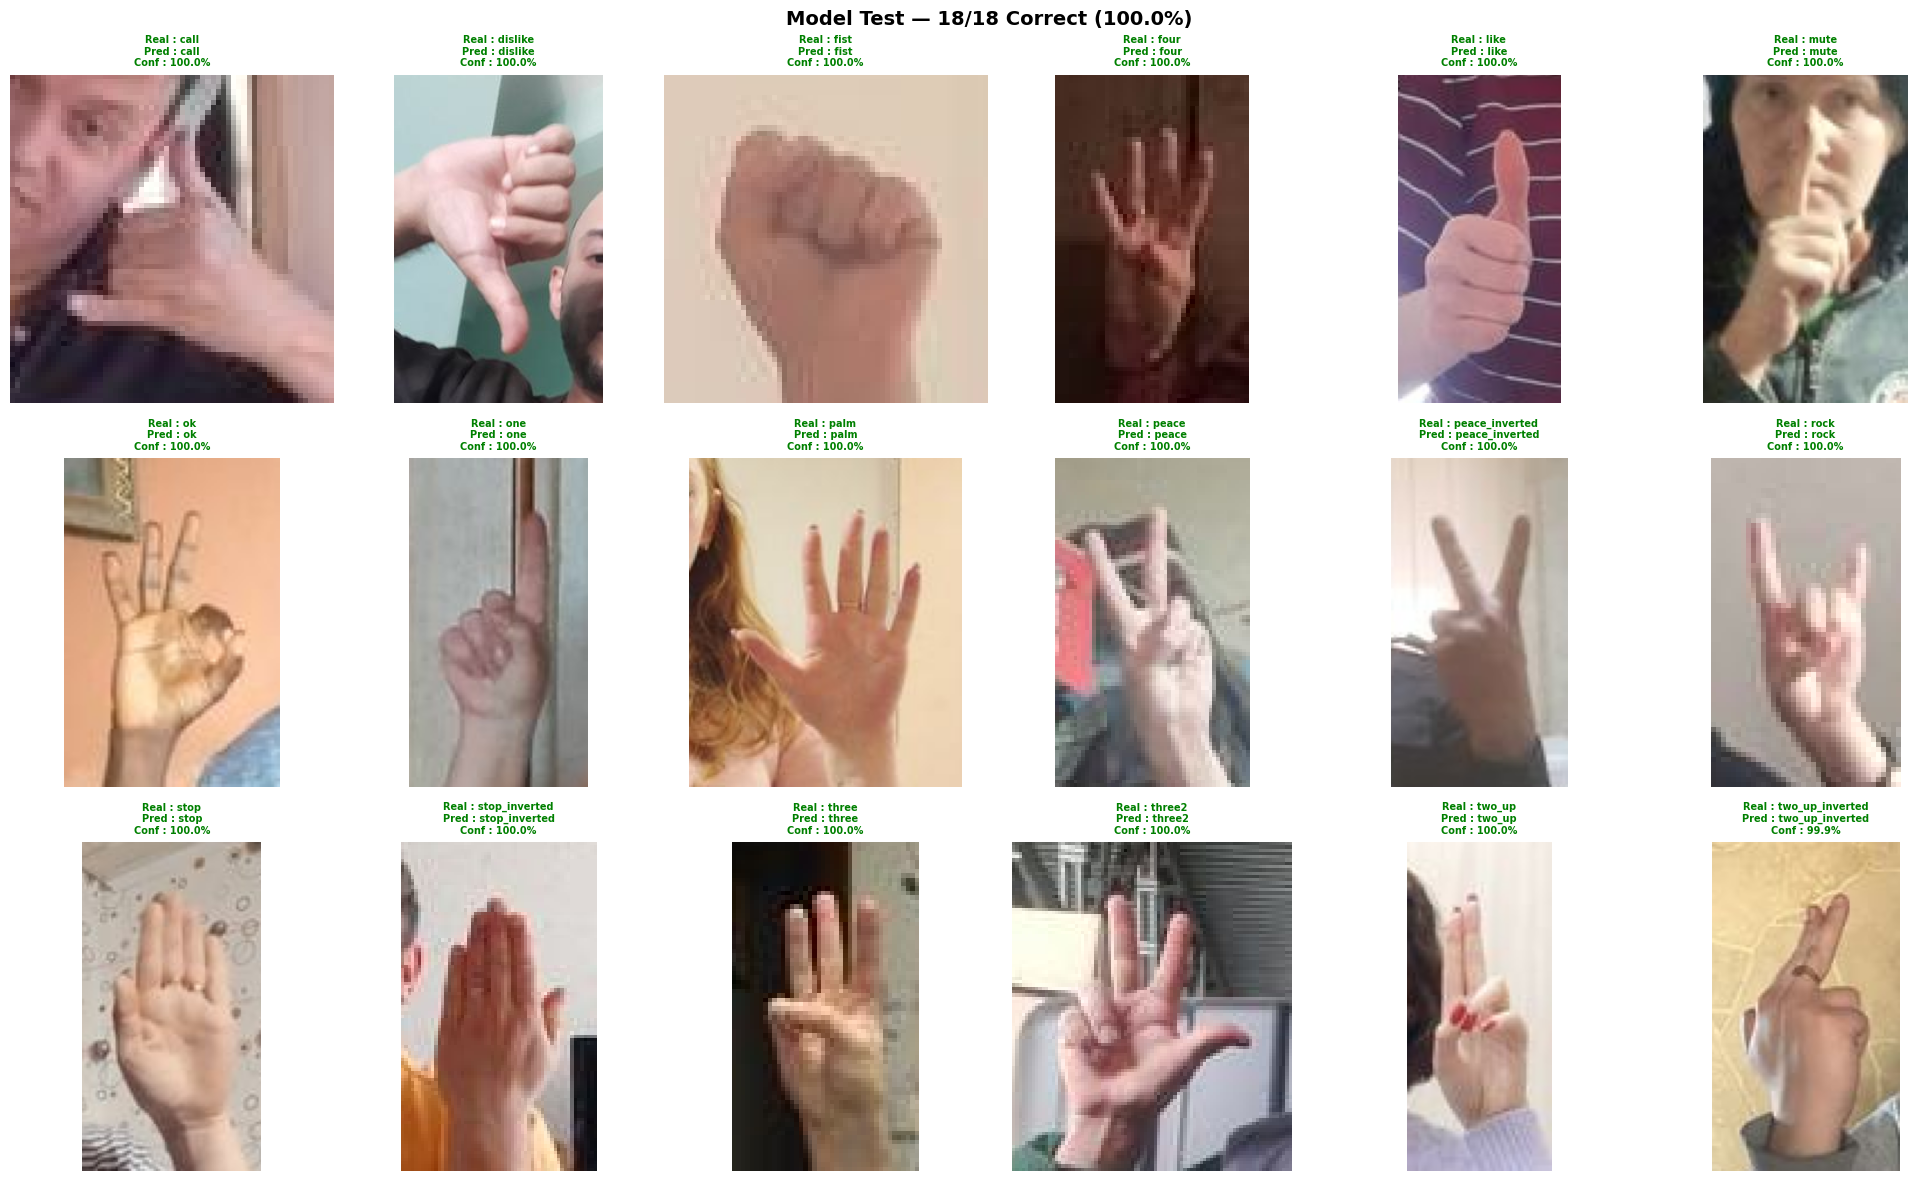


 Tested 18 samples: 18 correct (100.0%)


In [16]:
model.load_state_dict(torch.load('best_model.pth'))
model.eval()

fig, axes = plt.subplots(3, 6, figsize=(20, 12))
axes = axes.flatten()

correct = 0
total   = 0

for ax, gesture in zip(axes, class_names):
    # Get random image + its annotation
    folder   = f'{img_base}/train_val_{gesture}'
    ann_file = f'{ann_base}/{gesture}.json'
    img_path = random.choice(glob(f'{folder}/*.jpg'))
    img_id   = os.path.basename(img_path).replace('.jpg', '')
    img      = Image.open(img_path).convert('RGB')
    w, h     = img.size

    # Load annotation and crop hand
    with open(ann_file) as f:
        anns = json.load(f)

    if img_id in anns:
        ann    = anns[img_id]
        labels = ann['labels']
        bboxes = ann['bboxes']
        for label, bbox in zip(labels, bboxes):
            if label == gesture:
                x, y, bw, bh = bbox
                pad_x = int(bw * w * 0.20)
                pad_y = int(bh * h * 0.20)
                x1 = max(0, int(x*w) - pad_x)
                y1 = max(0, int(y*h) - pad_y)
                x2 = min(w, int((x+bw)*w) + pad_x)
                y2 = min(h, int((y+bh)*h) + pad_y)
                if x2 > x1 and y2 > y1:
                    img = img.crop((x1, y1, x2, y2))
                break

    # Predict
    input_tensor = val_transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        output         = model(input_tensor)
        probs          = torch.softmax(output, dim=1)
        conf, pred_idx = probs.max(1)
        predicted      = idx_to_class[pred_idx.item()]
        confidence     = conf.item() * 100

    is_correct = predicted == gesture
    if is_correct:
        correct += 1
    total += 1

    color = 'green' if is_correct else 'red'
    ax.imshow(img)
    ax.set_title(
        f'Real : {gesture}\nPred : {predicted}\nConf : {confidence:.1f}%',
        fontsize=7, color=color, weight='bold'
    )
    ax.axis('off')

plt.suptitle(f'Model Test — {correct}/{total} Correct ({100*correct/total:.1f}%)',
             fontsize=14, weight='bold')
plt.tight_layout()
plt.show()
print(f'\n Tested {total} samples: {correct} correct ({100*correct/total:.1f}%)')

#Security Action Mapping
### This maps each of the 18 HaGRID gesture classes to a meaningful security
### system action. In a real deployment, these strings would trigger actual
### system events (lock/unlock doors, send alerts, mute alarms, etc.).

## Design principle: intuitive mappings where possible
###   'like' (thumbs up) → Access Granted   (universal positive signal)
###   'dislike'          → Access Denied    (universal negative signal)
###   'fist'             → Alert Triggered  (aggressive/urgent gesture)
###   'palm' / 'stop'    → Halt / Stop      (natural stop signal)

In [17]:
SECURITY_ACTIONS = {
    'call'           : '📞 CALLING FOR HELP',
    'dislike'        : '❌ ACCESS DENIED',
    'fist'           : '🚨 ALERT TRIGGERED',
    'four'           : '4️⃣  SIGNAL FOUR',
    'like'           : '✅ ACCESS GRANTED',
    'mute'           : '🔇 SYSTEM MUTED',
    'ok'             : '✅ ALL CLEAR',
    'one'            : '☝️  SIGNAL ONE',
    'palm'           : '✋ HALT — STOP',
    'peace'          : '✌️  PEACE — STANDBY',
    'peace_inverted' : '⚠️  WARNING',
    'rock'           : '🤘 SIGNAL ROCK',
    'stop'           : '🛑 SYSTEM STOP',
    'stop_inverted'  : '🔄 SYSTEM RESUME',
    'three'          : '3️⃣  SIGNAL THREE',
    'three2'         : '3️⃣  SIGNAL THREE ALT',
    'two_up'         : '✌️  SIGNAL TWO',
    'two_up_inverted': '⚠️  CAUTION',
}

print(' Security actions mapped!\n')
for gesture, action in SECURITY_ACTIONS.items():
    print(f'   {gesture:<20} → {action}')

 Security actions mapped!

   call                 → 📞 CALLING FOR HELP
   dislike              → ❌ ACCESS DENIED
   fist                 → 🚨 ALERT TRIGGERED
   four                 → 4️⃣  SIGNAL FOUR
   like                 → ✅ ACCESS GRANTED
   mute                 → 🔇 SYSTEM MUTED
   ok                   → ✅ ALL CLEAR
   one                  → ☝️  SIGNAL ONE
   palm                 → ✋ HALT — STOP
   peace                → ✌️  PEACE — STANDBY
   peace_inverted       → ⚠️  WARNING
   rock                 → 🤘 SIGNAL ROCK
   stop                 → 🛑 SYSTEM STOP
   stop_inverted        → 🔄 SYSTEM RESUME
   three                → 3️⃣  SIGNAL THREE
   three2               → 3️⃣  SIGNAL THREE ALT
   two_up               → ✌️  SIGNAL TWO
   two_up_inverted      → ⚠️  CAUTION


Hand detector


In [21]:
#Install MediaPipe for Hand Detection
!pip install mediapipe==0.10.9 -q
print(' Done! Now restart the runtime and rerun from the camera cell')

ERROR: Could not find a version that satisfies the requirement mediapipe==0.10.9 (from versions: 0.10.13, 0.10.14, 0.10.15, 0.10.18, 0.10.20, 0.10.21, 0.10.30, 0.10.31, 0.10.32, 0.10.33)
ERROR: No matching distribution found for mediapipe==0.10.9
 Done! Now restart the runtime and rerun from the camera cell


In [23]:
!pip install mediapipe

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 58.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 11.1 MB/s eta 0:00:00
  Attempting uninstall: absl-py
    Found existing installation: absl-py 1.4.0
    Uninstalling absl-py-1.4.0:
      Successfully uninstalled absl-py-1.4.0


In [24]:
# Rebuild hand detector with lower threshold
# Run this cell BEFORE the live camera cell.
# Lower confidence thresholds = detects hands more aggressively.

from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import urllib.request, os

# Re-download model if needed
if not os.path.exists('hand_landmarker.task'):
    model_url = 'https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task'
    urllib.request.urlretrieve(model_url, 'hand_landmarker.task')
    print('✅ Model downloaded')

base_options  = python.BaseOptions(model_asset_path='hand_landmarker.task')
options       = vision.HandLandmarkerOptions(
    base_options=base_options,
    num_hands=2,
    min_hand_detection_confidence=0.2,   # was 0.5 — much more permissive
    min_hand_presence_confidence=0.2,    # was 0.5
    min_tracking_confidence=0.2          # was 0.5
)
hand_detector = vision.HandLandmarker.create_from_options(options)
print(' Hand detector rebuilt with lower thresholds!')


#Improved detect_and_crop_hand

import mediapipe as mp
import numpy as np

def detect_and_crop_hand(img_pil):
    """
    Detect hand and crop. Fixes vs original:
      - Tries both the original and horizontally flipped frame
        (selfie cameras mirror; MediaPipe can struggle with mirrored hands)
      - Higher resolution input (no downscaling before detection)
      - Returns the crop from whichever orientation found a hand
    """
    w, h = img_pil.size

    def _try_detect(image_pil):
        img_rgb  = np.array(image_pil, dtype=np.uint8)
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
        result   = hand_detector.detect(mp_image)
        return result

    # Try original orientation first
    result = _try_detect(img_pil)

    # If no hand found, try flipping horizontally (fixes mirrored selfie cameras)
    flipped = False
    if not result.hand_landmarks:
        import PIL.ImageOps
        img_flipped = img_pil.transpose(Image.FLIP_LEFT_RIGHT)
        result = _try_detect(img_flipped)
        if result.hand_landmarks:
            flipped = True
            img_pil = img_flipped  # use flipped version for crop

    if result.hand_landmarks:
        landmarks = result.hand_landmarks[0]
        x_coords  = [lm.x for lm in landmarks]
        y_coords  = [lm.y for lm in landmarks]

        x_min = max(0.0, min(x_coords))
        y_min = max(0.0, min(y_coords))
        x_max = min(1.0, max(x_coords))
        y_max = min(1.0, max(y_coords))

        # 30% padding (slightly more than training's 20% for robustness)
        pad_x = (x_max - x_min) * 0.30
        pad_y = (y_max - y_min) * 0.30

        x1 = max(0, int((x_min - pad_x) * w))
        y1 = max(0, int((y_min - pad_y) * h))
        x2 = min(w, int((x_max + pad_x) * w))
        y2 = min(h, int((y_max + pad_y) * h))

        if x2 > x1 and y2 > y1:
            return img_pil.crop((x1, y1, x2, y2)), True

    # No hand found at all — return full frame
    return img_pil, False


#  Quick debug test run this to check if your camera frame works
# Paste one frame from the camera into a PIL image and call:
#
#   cropped, found = detect_and_crop_hand(your_pil_image)
#   print("Hand found:", found)
#   display(cropped)
#
# If still not found after running this, the issue is lighting or camera feed quality.

print(' detect_and_crop_hand (fixed) ready!')
print()
print(' Checklist if hand still not detected:')
print('   1. Is your hand fully visible and well-lit?')
print('   2. Is your hand close enough to the camera (arm length or closer)?')
print('   3. Try spreading your fingers wide — a flat open palm detects best')
print('   4. Avoid dark backgrounds or strong backlighting')

✅ Model downloaded
 Hand detector rebuilt with lower thresholds!
 detect_and_crop_hand (fixed) ready!

 Checklist if hand still not detected:
   1. Is your hand fully visible and well-lit?
   2. Is your hand close enough to the camera (arm length or closer)?
   3. Try spreading your fingers wide — a flat open palm detects best
   4. Avoid dark backgrounds or strong backlighting


Test Hand Detector on a Dataset Image

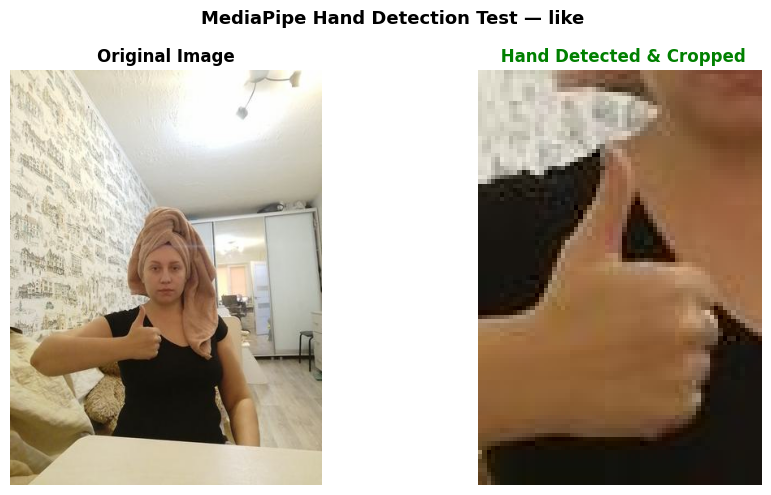

Hand detected:  Yes


In [25]:
# Test the hand detector on a sample image from our dataset
test_gesture = 'like'
test_folder  = f'{img_base}/train_val_{test_gesture}'
test_img_path = random.choice(glob(f'{test_folder}/*.jpg'))
test_img     = Image.open(test_img_path).convert('RGB')

cropped, hand_found = detect_and_crop_hand(test_img)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.imshow(test_img)
ax1.set_title('Original Image', fontsize=12, weight='bold')
ax1.axis('off')

ax2.imshow(cropped)
ax2.set_title(
    ' Hand Detected & Cropped' if hand_found else ' No Hand Found',
    fontsize=12, weight='bold',
    color='green' if hand_found else 'orange'
)
ax2.axis('off')

plt.suptitle(f'MediaPipe Hand Detection Test — {test_gesture}', fontsize=13, weight='bold')
plt.tight_layout()
plt.show()

print(f'Hand detected: {" Yes" if hand_found else " No"}')

In [26]:
SECURITY_ACTIONS = {
    'call'           : '📞 CALLING FOR HELP',
    'dislike'        : '❌ ACCESS DENIED',
    'fist'           : '🚨 ALERT TRIGGERED',
    'four'           : '4️⃣  SIGNAL FOUR',
    'like'           : '✅ ACCESS GRANTED',
    'mute'           : '🔇 SYSTEM MUTED',
    'ok'             : '✅ ALL CLEAR',
    'one'            : '☝️  SIGNAL ONE',
    'palm'           : '✋ HALT - STOP',
    'peace'          : '✌️  PEACE - STANDBY',
    'peace_inverted' : '⚠️  WARNING',
    'rock'           : '🤘 SIGNAL ROCK',
    'stop'           : '🛑 SYSTEM STOP',
    'stop_inverted'  : '🔄 SYSTEM RESUME',
    'three'          : '3️⃣  SIGNAL THREE',
    'three2'         : '3️⃣  SIGNAL THREE ALT',
    'two_up'         : '✌️  SIGNAL TWO',
    'two_up_inverted': '⚠️  CAUTION',
}
print(' Security actions ready!')

 Security actions ready!


Live Camera Gesture Recognition


In [29]:
from IPython.display import display, Javascript
from google.colab import output
from base64 import b64decode
import io, time
import numpy as np
from PIL import Image
import torch


# 1. Inject the camera into the page (one-time setup)

display(Javascript("""
    // Clean up any previous instance
    var old = document.getElementById('gest-container');
    if (old) old.remove();
    window._gestStream  = null;
    window._gestRunning = false;

    // ── Outer container ───────────────────────────────────────────────────────
    var container = document.createElement('div');
    container.id = 'gest-container';
    Object.assign(container.style, {
        position: 'fixed', top: '0', left: '0',
        width: '100%', height: '100%',
        backgroundColor: '#0a0a0a', zIndex: '9999',
        display: 'flex', flexDirection: 'column',
        alignItems: 'center', justifyContent: 'center',
        gap: '12px'
    });

    // ── Video ─────────────────────────────────────────────────────────────────
    var video = document.createElement('video');
    video.id = 'gest-video';
    Object.assign(video.style, {
        width: '88%', maxHeight: '65vh',
        objectFit: 'contain',
        border: '3px solid #00ff00',
        borderRadius: '12px',
        boxShadow: '0 0 25px rgba(0,255,0,0.3)'
    });
    video.setAttribute('autoplay', '');
    video.setAttribute('playsinline', '');
    video.muted = true;

    // ── Info overlay ──────────────────────────────────────────────────────────
    var info = document.createElement('div');
    info.id = 'gest-info';
    Object.assign(info.style, {
        width: '88%', backgroundColor: 'rgba(0,0,0,0.85)',
        color: 'white', padding: '14px 20px',
        borderRadius: '10px', fontFamily: 'monospace',
        textAlign: 'center', fontSize: '16px', lineHeight: '1.6'
    });
    info.innerHTML = '<span style="opacity:0.6">⏳ Starting camera...</span>';

    // ── Stop button ───────────────────────────────────────────────────────────
    var btn = document.createElement('button');
    btn.textContent = '✕  STOP CAMERA';
    Object.assign(btn.style, {
        position: 'absolute', top: '16px', right: '20px',
        padding: '10px 22px', backgroundColor: '#cc0000',
        color: 'white', border: 'none', borderRadius: '6px',
        cursor: 'pointer', fontSize: '15px', fontWeight: 'bold',
        zIndex: '10001'
    });

    container.appendChild(video);
    container.appendChild(info);
    container.appendChild(btn);
    document.body.appendChild(container);

    // ── Hidden canvas for frame capture ───────────────────────────────────────
    var canvas = document.createElement('canvas');
    var ctx    = canvas.getContext('2d');

    // ── Expose helpers that Python will call via eval_js ──────────────────────

    // Returns current frame as base64 JPEG (called by Python pull loop)
    window.grabFrame = function() {
        if (!video || video.videoWidth === 0) return '';
        canvas.width  = video.videoWidth;
        canvas.height = video.videoHeight;
        ctx.drawImage(video, 0, 0);
        return canvas.toDataURL('image/jpeg', 0.90);   // higher quality
    };

    // Called by Python to update the overlay
    window.updateOverlay = function(html, borderColor) {
        var i = document.getElementById('gest-info');
        var v = document.getElementById('gest-video');
        if (i) i.innerHTML = html;
        if (v) {
            v.style.borderColor = borderColor;
            v.style.boxShadow   = '0 0 25px ' + borderColor + '55';
        }
    };

    // Expose running flag
    window._gestRunning = true;

    // Start camera
    navigator.mediaDevices.getUserMedia({
        video: { width: {ideal: 1280}, height: {ideal: 720}, facingMode: 'user' }
    }).then(function(stream) {
        window._gestStream = stream;
        video.srcObject    = stream;
        return video.play();
    }).then(function() {
        info.innerHTML = '<span style="color:#00ff00">✅ Camera ready — show your hand!</span>';
    }).catch(function(err) {
        info.innerHTML = '<span style="color:red">❌ Camera error: ' + err.message + '</span>';
        window._gestRunning = false;
    });

    // Stop button
    btn.onclick = function() {
        window._gestRunning = false;
        if (window._gestStream)
            window._gestStream.getTracks().forEach(function(t){ t.stop(); });
        container.remove();
    };
"""))

time.sleep(2)   # give browser time to open camera
print("🎥 Camera injected. Starting inference loop...\n")


# ── 2. Python pull-loop (reliable frame transfer) ─────────────────────────────

# ── Replace ONLY the run_inference_loop function ─────────────────────────────

def run_inference_loop(max_frames=2000):

    model.eval()
    frame_count = 0

    for _ in range(max_frames):

        # ── Check if user clicked STOP ────────────────────────────────────────
        still_running = output.eval_js("window._gestRunning || false")
        if not still_running:
            print("🛑 Camera stopped by user.")
            break

        # ── Pull frame from browser ───────────────────────────────────────────
        data_url = output.eval_js("window.grabFrame()")
        if not data_url or not data_url.startswith('data:image'):
            time.sleep(0.1)
            continue

        # ── Decode ────────────────────────────────────────────────────────────
        try:
            raw = b64decode(data_url.split(',')[1])
            img = Image.open(io.BytesIO(raw)).convert('RGB')
        except Exception:
            time.sleep(0.1)
            continue

        # ── Hand detection ────────────────────────────────────────────────────
        cropped, hand_found = detect_and_crop_hand(img)

        # ── NO HAND → show waiting message, skip model entirely ───────────────
        if not hand_found:
            html = """
                <div style="font-size:20px;margin-bottom:6px;">🔐 SECURITY SYSTEM ACTIVE</div>
                <div style="font-size:26px;color:#888;font-weight:bold;">✋ NO GESTURE DETECTED</div>
                <div style="font-size:15px;color:#666;margin-top:8px;">
                    Show your hand to the camera
                </div>
            """
            safe_html = html.replace('`', "'")
            output.eval_js(f"window.updateOverlay(`{safe_html}`, '#444444')")
            time.sleep(0.18)
            continue   # ← skip everything below, go to next frame

        # ── HAND FOUND → run model ────────────────────────────────────────────
        tensor = val_transform(cropped).unsqueeze(0).to(device)
        with torch.no_grad():
            probs = torch.softmax(model(tensor), dim=1)[0]

        top5_conf, top5_idx = probs.topk(5)
        results = [(idx_to_class[i.item()], c.item()*100)
                   for i, c in zip(top5_idx, top5_conf)]

        top_gesture, top_conf = results[0]
        action = SECURITY_ACTIONS.get(top_gesture, '❓ UNKNOWN')

        color = '#00ff00' if top_conf > 80 else '#ffaa00' if top_conf > 55 else '#ff8800'

        top3_html = ''.join(
            f'<div style="font-size:13px;opacity:0.75;">#{i+1} {g} — {c:.1f}%</div>'
            for i, (g, c) in enumerate(results[:3])
        )

        html = f"""
            <div style="font-size:20px;margin-bottom:4px;">🔐 SECURITY SYSTEM ACTIVE</div>
            <div style="font-size:30px;color:{color};font-weight:bold;">{top_gesture.upper()}</div>
            <div style="font-size:21px;margin:4px 0;">{action}</div>
            <div style="font-size:18px;color:{color};">Confidence: {top_conf:.1f}%</div>
            <div style="font-size:13px;opacity:0.7;margin:3px 0;">✋ Hand detected</div>
            {top3_html}
            <div style="font-size:11px;opacity:0.4;margin-top:6px;">Frame #{frame_count}</div>
        """

        safe_html = html.replace('`', "'")
        output.eval_js(f"window.updateOverlay(`{safe_html}`, '{color}')")

        frame_count += 1
        time.sleep(0.18)

    print(f"✅ Done — {frame_count} frames with hand detected.")


# ── Re-run the camera ─────────────────────────────────────────────────────────
print("Starting — overlay will only show predictions when a hand is visible.\n")
run_inference_loop()


# ── 3. Run ────────────────────────────────────────────────────────────────────
print("Starting inference — the overlay will update as you show gestures.")
print("Click ✕ STOP CAMERA at any time.\n")
run_inference_loop()

<IPython.core.display.Javascript object>

🎥 Camera injected. Starting inference loop...

Starting — overlay will only show predictions when a hand is visible.

🛑 Camera stopped by user.
✅ Done — 5 frames with hand detected.
Starting inference — the overlay will update as you show gestures.
Click ✕ STOP CAMERA at any time.

🛑 Camera stopped by user.
✅ Done — 0 frames with hand detected.
